# Zomato Restaurant Cost Prediction

## Problem Statement

In the competitive restaurant industry, understanding and predicting the cost of dining is crucial for both customers and restaurant owners. This project focuses on predicting the approximate cost for two people at restaurants in Bangalore, India, using data from Zomato.

### Business Context

Zomato is a popular restaurant discovery and food delivery platform that provides information about restaurants, including ratings, reviews, cuisines, and pricing. The approximate cost for two people is an important factor that influences customer decisions and helps restaurants position themselves in the market.

The goal of this analysis is to build a machine learning model that can accurately predict the cost for two people based on various features such as:
- Online order availability
- Table booking options
- Number of votes
- Location
- Restaurant type
- Cuisines offered
- Other relevant attributes

### Objectives

1. Perform comprehensive exploratory data analysis (EDA) to understand the dataset and identify key patterns.
2. Clean and preprocess the data for modeling.
3. Engineer features to improve model performance.
4. Train and evaluate multiple machine learning models.
5. Select the best performing model for cost prediction.

This notebook will demonstrate the end-to-end process of data analysis, preprocessing, and model building using the Zomato dataset.

## Notebook and Dataset Location

This notebook is located outside the main project folder for better organization. The dataset used is `zomato_dataset.csv`, which is also placed outside the main project directory.

- Notebook file: Zomato_Cost_Prediction.ipynb
- Dataset file: zomato_dataset.csv


In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from kneed import KneeLocator
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [4]:
# Load Dataset and Initial Inspection

# Load the dataset
df = pd.read_csv('zomato.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (51717, 17)

Column Names:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Data Types:
url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object

First 5 rows:


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
df.describe()


Missing Values:
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Summary Statistics:


,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


## Exploratory Data Analysis (EDA)

In this section, we will explore the dataset to understand the distributions, relationships, and patterns in the data.

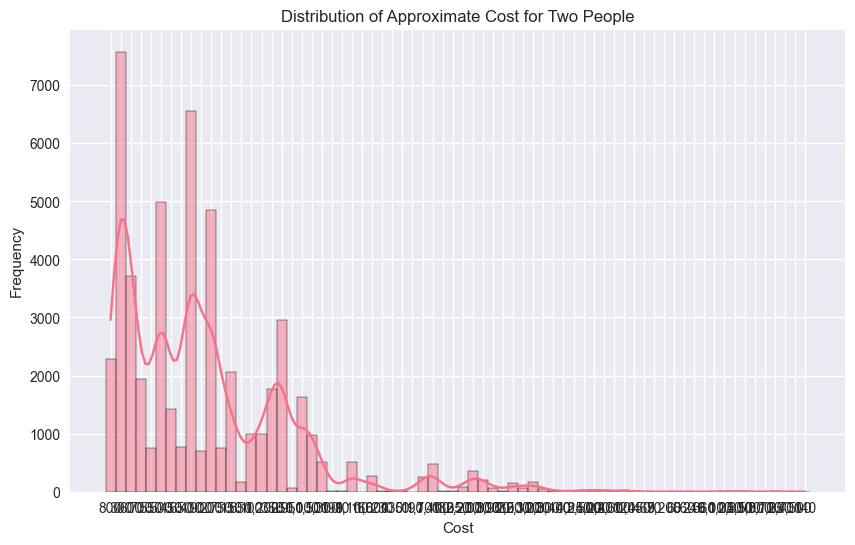

Target variable statistics:
count     51371
unique       70
top         300
freq       7576
Name: approx_cost(for two people), dtype: object


In [7]:
# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['approx_cost(for two people)'], bins=50, kde=True)
plt.title('Distribution of Approximate Cost for Two People')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

print("Target variable statistics:")
print(df['approx_cost(for two people)'].describe())

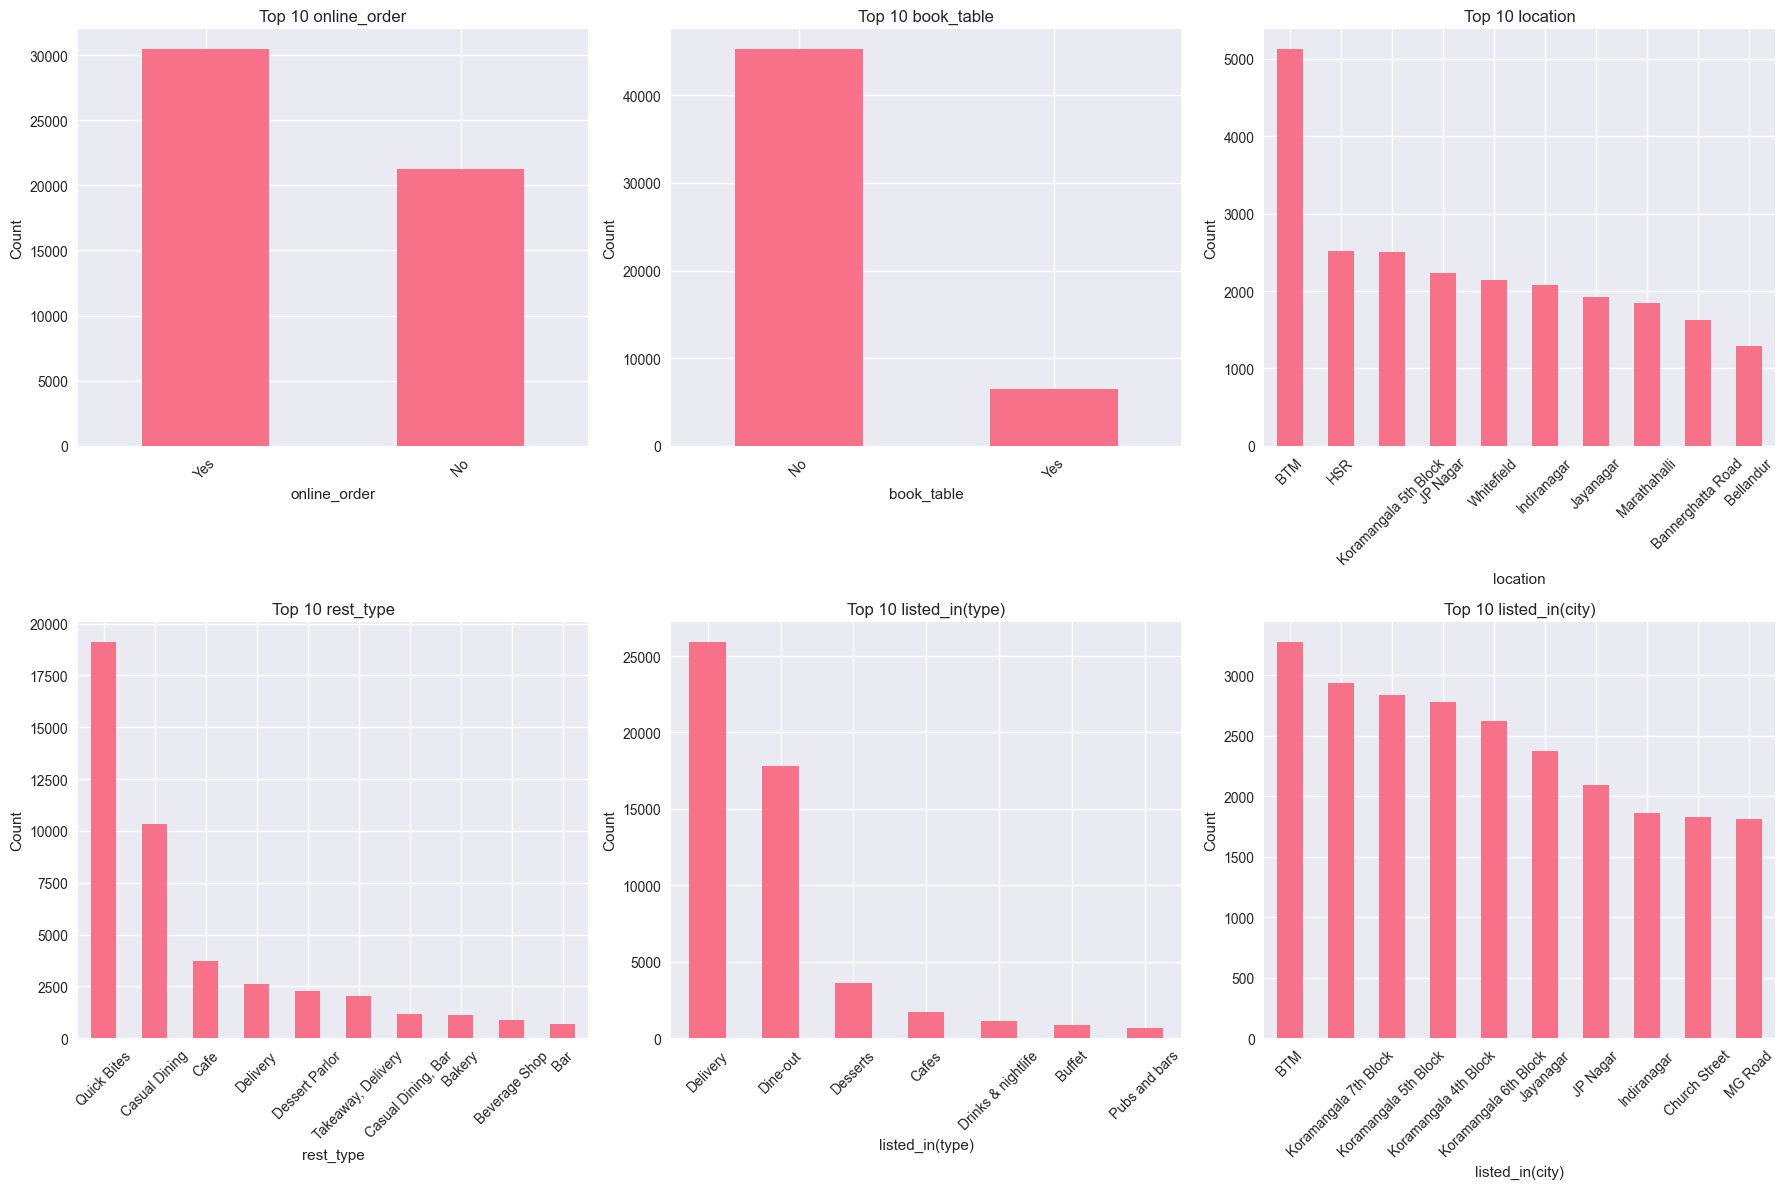

In [8]:
# Explore categorical variables
categorical_cols = ['online_order', 'book_table', 'location', 'rest_type', 'listed_in(type)', 'listed_in(city)']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    ax = axes[i//3, i%3]
    if col in df.columns:
        top_10 = df[col].value_counts().head(10)
        top_10.plot(kind='bar', ax=ax)
        ax.set_title(f'Top 10 {col}')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

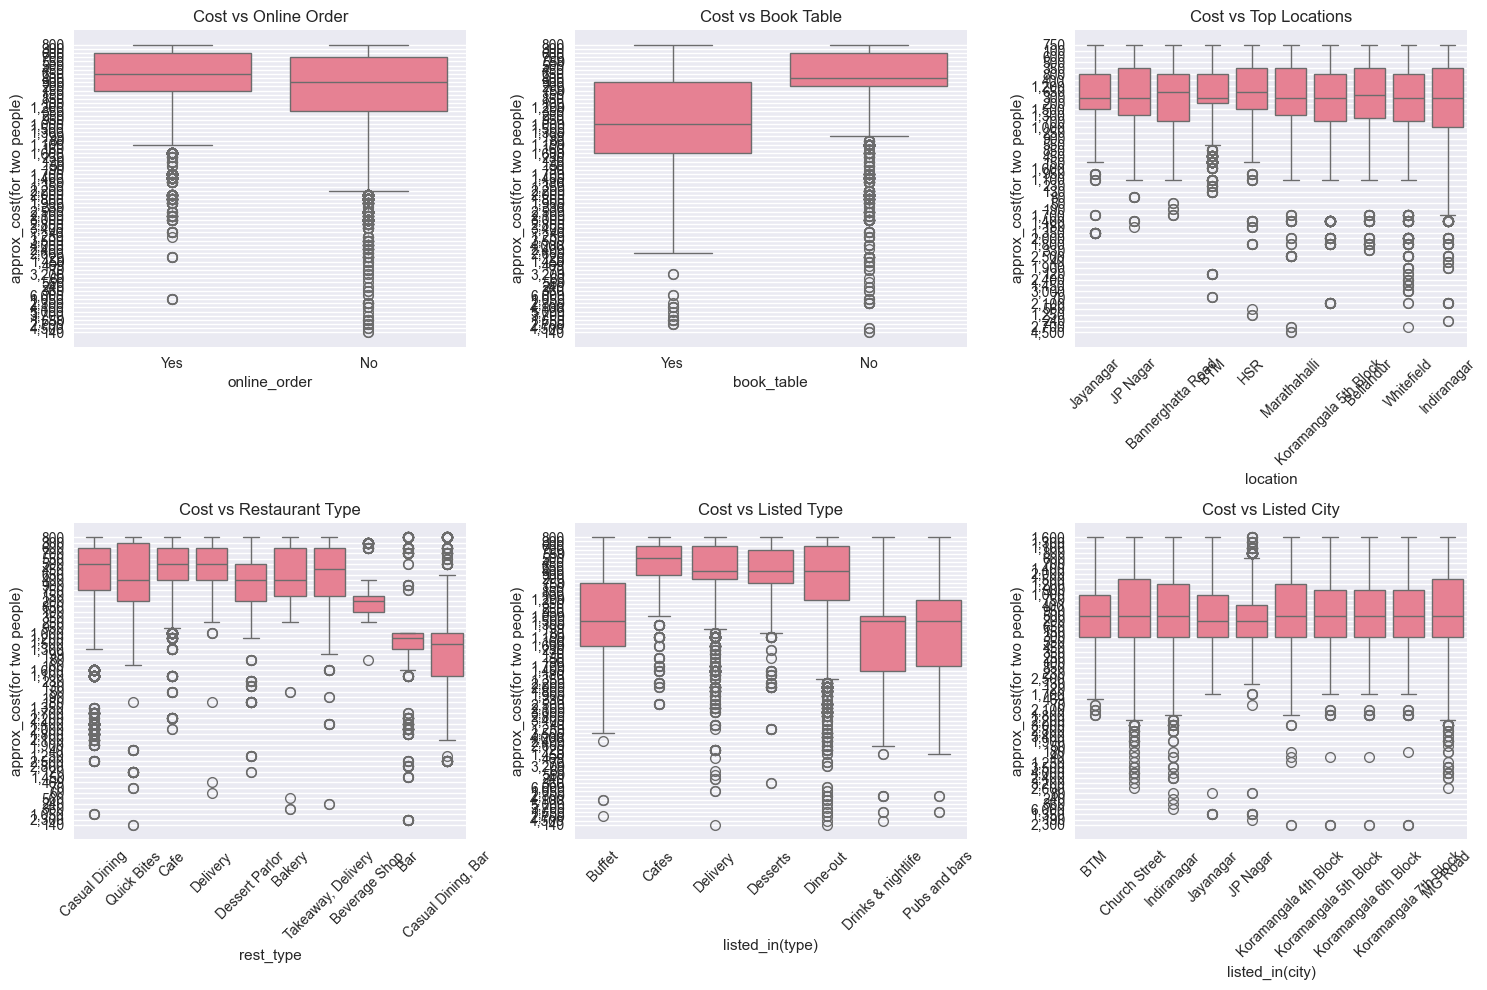

In [9]:
# Relationship between categorical variables and target
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.boxplot(x='online_order', y='approx_cost(for two people)', data=df)
plt.title('Cost vs Online Order')

plt.subplot(2, 3, 2)
sns.boxplot(x='book_table', y='approx_cost(for two people)', data=df)
plt.title('Cost vs Book Table')

plt.subplot(2, 3, 3)
top_locations = df['location'].value_counts().head(10).index
sns.boxplot(x='location', y='approx_cost(for two people)', data=df[df['location'].isin(top_locations)])
plt.title('Cost vs Top Locations')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
top_types = df['rest_type'].value_counts().head(10).index
sns.boxplot(x='rest_type', y='approx_cost(for two people)', data=df[df['rest_type'].isin(top_types)])
plt.title('Cost vs Restaurant Type')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
sns.boxplot(x='listed_in(type)', y='approx_cost(for two people)', data=df)
plt.title('Cost vs Listed Type')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
top_cities = df['listed_in(city)'].value_counts().head(10).index
sns.boxplot(x='listed_in(city)', y='approx_cost(for two people)', data=df[df['listed_in(city)'].isin(top_cities)])
plt.title('Cost vs Listed City')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

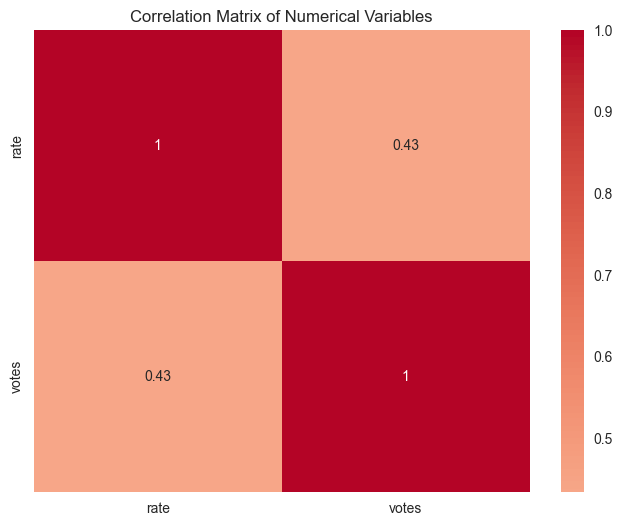

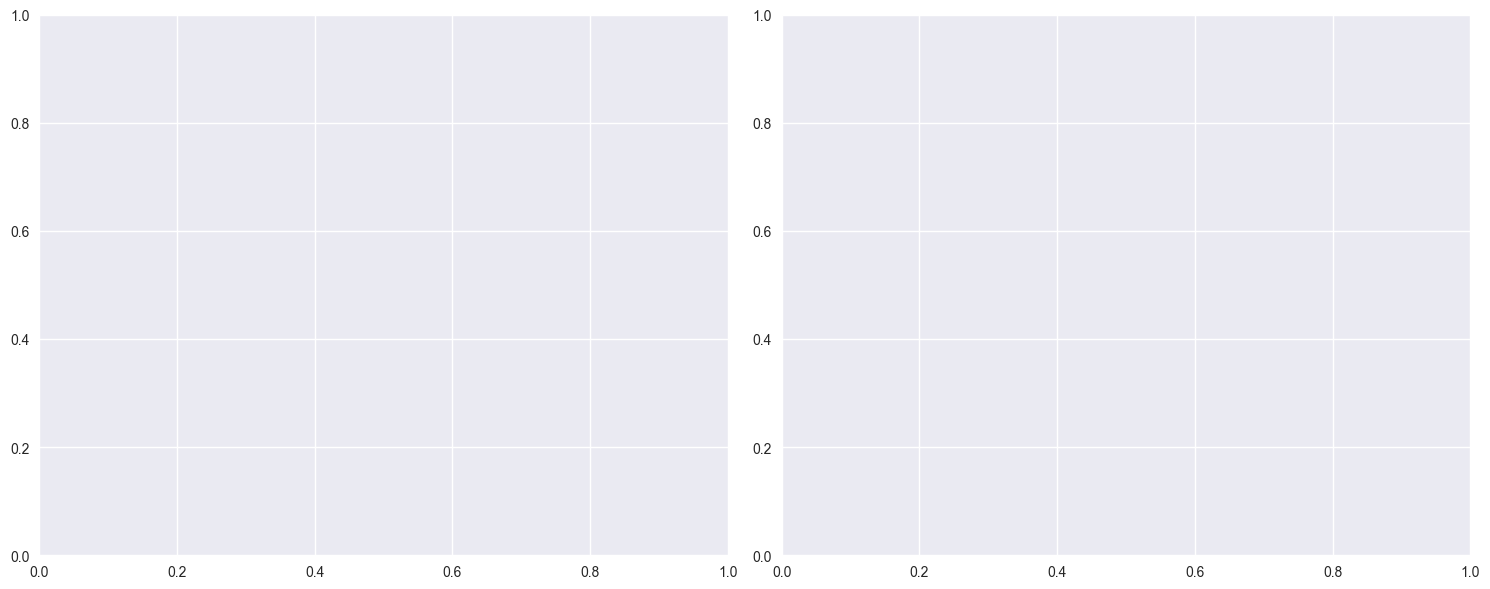

In [24]:
# Correlation analysis for numerical variables
# First, let's see the rate column - need to clean it
df_clean = df.copy()
df_clean = df_clean[df_clean['rate'] != 'NEW']
df_clean = df_clean[df_clean['rate'] != '-']
df_clean['rate'] = df_clean['rate'].str.replace('/5', '').astype(float)

numerical_cols = ['rate', 'votes', 'approx_cost(for two people)']
correlation_matrix = df_clean[numerical_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


plt.tight_layout()
plt.show()

## Data Cleaning and Feature Engineering

In this section, we will clean the data and prepare features for modeling.

In [26]:
# Data Cleaning
# Drop unnecessary columns as identified in EDA
columns_to_drop = ['url', 'address', 'name', 'phone', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']
df_clean = df.drop(columns_to_drop, axis=1)

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Handle missing values - drop rows with missing values for simplicity
df_clean = df_clean.dropna()

# Clean rate column
df_clean = df_clean[df_clean['rate'] != 'NEW']
df_clean = df_clean[df_clean['rate'] != '-']
df_clean['rate'] = df_clean['rate'].str.replace('/5', '').astype(float)

# Convert cost to float
df_clean['approx_cost(for two people)'] = df_clean['approx_cost(for two people)'].astype(str)
df_clean['approx_cost(for two people)'] = df_clean['approx_cost(for two people)'].str.replace(',', '.')
df_clean['approx_cost(for two people)'] = df_clean['approx_cost(for two people)'].astype(float)

print("Shape after cleaning:", df_clean.shape)
print("Columns after cleaning:", df_clean.columns.tolist())

Shape after cleaning: (11133, 9)
Columns after cleaning: ['online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)']


In [28]:
# Feature Engineering
# Encode categorical variables
df_encoded = df_clean.copy()

# Binary encoding for yes/no columns
df_encoded['online_order'] = df_encoded['online_order'].map({'Yes': 1, 'No': 0})
df_encoded['book_table'] = df_encoded['book_table'].map({'Yes': 1, 'No': 0})

# Label encoding for other categorical columns
categorical_cols = ['location', 'rest_type', 'dish_liked', 'cuisines']
for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Data types after encoding:")
print(df_encoded.dtypes)
print("\nFirst 5 rows of encoded data:")
df_encoded.head()

Data types after encoding:
online_order                     int64
book_table                       int64
rate                           float64
votes                            int64
location                         int32
rest_type                        int32
dish_liked                       int32
cuisines                         int32
approx_cost(for two people)    float64
dtype: object

First 5 rows of encoded data:


,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people)
0,1,1,4.1,775,1,20,3604,1386,800.0
1,1,0,4.1,787,1,20,2930,594,800.0
2,1,0,3.8,918,1,16,1398,484,800.0
3,0,0,3.7,88,1,62,2732,1587,300.0
4,0,0,3.8,166,4,20,3412,1406,600.0


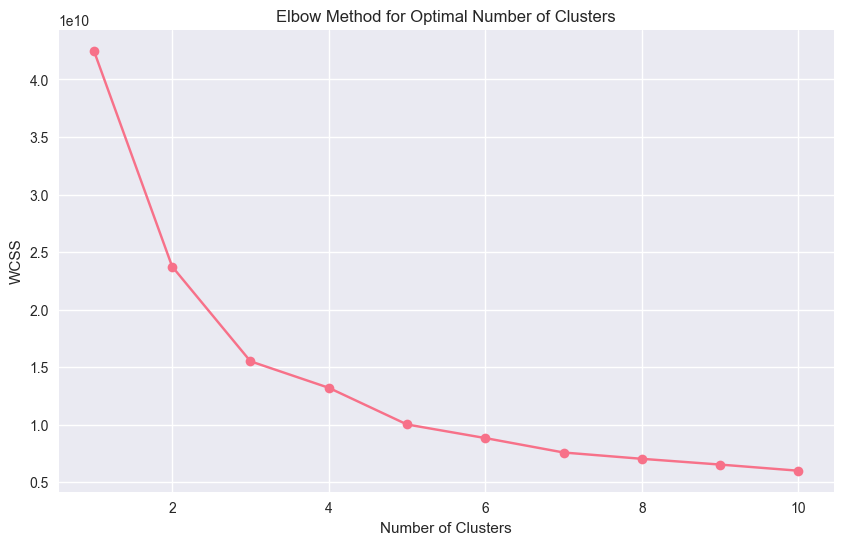

Optimal number of clusters: 3
Cluster distribution:
Cluster
1    5394
0    5305
2     434
Name: count, dtype: int64


In [30]:
# Clustering Analysis
# Prepare features for clustering (exclude target)
X_cluster = df_encoded.drop('approx_cost(for two people)', axis=1)

# Elbow method to find optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Find optimal clusters using KneeLocator
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_clusters = kl.knee
print(f"Optimal number of clusters: {optimal_clusters}")

# Perform clustering
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42)
df_encoded['Cluster'] = kmeans.fit_predict(X_cluster)

print("Cluster distribution:")
print(df_encoded['Cluster'].value_counts())

## Train/Test Split and Preprocessing

In [33]:
# Prepare final dataset
X = df_encoded.drop(['approx_cost(for two people)', 'Cluster'], axis=1)
y = df_encoded['approx_cost(for two people)']
clusters = df_encoded['Cluster']

# Train-test split
X_train, X_test, y_train, y_test, clusters_train, clusters_test = train_test_split(
    X, y, clusters, test_size=0.2, random_state=42, stratify=clusters
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Training set shape: (8906, 8)
Test set shape: (2227, 8)
Features scaled successfully


## Baseline Model

We will start with a simple baseline model to establish a performance benchmark.

In [36]:
# Baseline Model - Mean Predictor
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_scaled, y_train)
y_pred_baseline = baseline.predict(X_test_scaled)

baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline Model Performance:")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R2 Score: {baseline_r2:.4f}")

# This will serve as our benchmark

Baseline Model Performance:
RMSE: 275.82
R2 Score: -0.0003


## Multiple Model Training and Comparison

Following the project approach, we will train models for each cluster separately and compare different algorithms.

In [ ]:
#As part of assignment, build multiple models and evaluate.